# Lesson 1 — Level sets, `|∇φ| = 1`, and reinitialization

Interactive companion to lesson 1. Prereq: none.

Goals:
1. Build a signed-distance function (SDF) for a shape and visualize it.
2. Verify `|∇φ| = 1` numerically.
3. See why `κ = Δφ` works (and only works) when `|∇φ| = 1`.
4. Watch advection break the SDF property.
5. Implement reinitialization and watch it restore `|∇φ| = 1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 128
L = 2.0
h = L / N
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y, indexing='xy')

Matplotlib is building the font cache; this may take a moment.


## 1. A signed-distance function for a circle

`φ(x, y) = sqrt(x² + y²) - R` is the exact SDF of a circle of radius `R`.

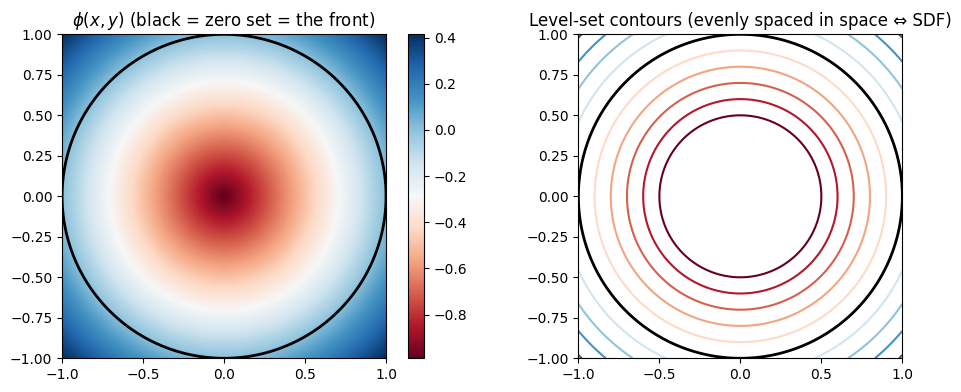

In [14]:
R = 1
phi = np.sqrt(X**2 + Y**2) - R

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im = ax[0].imshow(phi, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='RdBu')
ax[0].contour(X, Y, phi, levels=[0], colors='k', linewidths=2)
ax[0].set_title(r'$\phi(x,y)$ (black = zero set = the front)')
plt.colorbar(im, ax=ax[0])

# Level-set contours at multiple distances
ax[1].contour(X, Y, phi, levels=np.linspace(-0.5, 0.5, 11), cmap='RdBu')
ax[1].contour(X, Y, phi, levels=[0], colors='k', linewidths=2)
ax[1].set_aspect('equal')
ax[1].set_title('Level-set contours (evenly spaced in space ⇔ SDF)')
plt.tight_layout()
plt.show()

Notice the contours are **evenly spaced** in physical distance. That is the visual signature of an SDF. A non-SDF representation with the same zero set would have contours piling up or spreading out.

## 2. Verify `|∇φ| = 1`

|∇φ|: mean = 1.0075, min = 0.6229, max = 1.0079


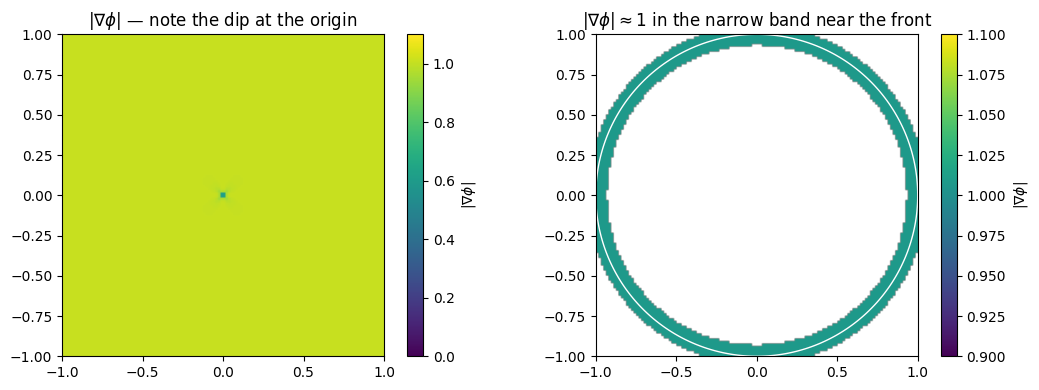

In [15]:
def grad_mag(phi, h):
    gy, gx = np.gradient(phi, h)
    return np.sqrt(gx**2 + gy**2)

mag = grad_mag(phi, h)
print(f'|∇φ|: mean = {mag.mean():.4f}, min = {mag.min():.4f}, max = {mag.max():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im0 = ax[0].imshow(mag, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='viridis', vmin=0, vmax=1.1)
plt.colorbar(im0, ax=ax[0], label=r'$|\nabla \phi|$')
ax[0].set_title(r'$|\nabla \phi|$ — note the dip at the origin')

# Restrict to a narrow band around the front — that's all the solver actually uses.
band = np.abs(phi) < 4*h
mag_band = np.where(band, mag, np.nan)
im1 = ax[1].imshow(mag_band, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='viridis', vmin=0.9, vmax=1.1)
plt.colorbar(im1, ax=ax[1], label=r'$|\nabla \phi|$')
ax[1].contour(X, Y, phi, levels=[0], colors='w', linewidths=1)
ax[1].set_title(r'$|\nabla \phi| \approx 1$ in the narrow band near the front')
plt.tight_layout()
plt.show()

**Why the dip at the origin?** The SDF `φ = √(x²+y²) − R` is a cone with its tip at the origin — not differentiable there. The finite-difference stencil straddles the tip symmetrically, so the derivatives cancel and `|∇φ|` collapses toward 0. Analytically `|∇φ|` is undefined at that one point; everywhere else it equals 1 exactly.

More generally, every SDF has a **skeleton** — the set of points equidistant from two or more nearest-surface points — where it's non-differentiable. For a circle the skeleton is just the center. For a square it's the two diagonals. Reinitialization *creates* skeletons: that's what "restore `|∇φ| = 1`" means, perpendicular flow from both sides meeting in the middle.

This is fine in practice because the solver only uses `φ` **near the front** (narrow band, `|φ| < few · h`), and the skeleton sits at the maxima of `|φ|` — as far from the front as possible. The right panel above clips to that band; within it, `|∇φ| ≈ 1` as advertised.

## 3. Counter-example: `ψ = x² + y² − R²`

Same zero set (the circle of radius R), but not a signed distance function.

|∇ψ|: mean = 1.5541, min = 0.0224, max = 2.8283


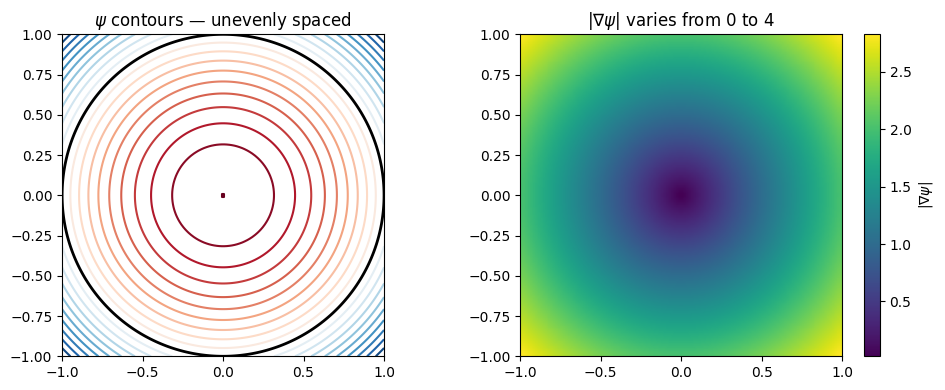

In [16]:
psi = X**2 + Y**2 - R**2
mag_psi = grad_mag(psi, h)
print(f'|∇ψ|: mean = {mag_psi.mean():.4f}, min = {mag_psi.min():.4f}, max = {mag_psi.max():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].contour(X, Y, psi, levels=np.linspace(psi.min(), psi.max(), 21), cmap='RdBu')
ax[0].contour(X, Y, psi, levels=[0], colors='k', linewidths=2)
ax[0].set_aspect('equal')
ax[0].set_title(r'$\psi$ contours — unevenly spaced')
im = ax[1].imshow(mag_psi, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax[1], label=r'$|\nabla \psi|$')
ax[1].set_title(r'$|\nabla \psi|$ varies from 0 to 4')
plt.tight_layout()
plt.show()

Both `φ` and `ψ` represent the same circle, but only `φ` has `|∇φ| = 1`. This matters for the three cheap operations below.

## 4. Geometry for free: normals and curvature

For the SDF: `n = ∇φ` (no division), `κ = Δφ`. For a circle of radius R, exact curvature is `κ = 1/R`.

In [ ]:
def laplacian(phi, h):
    # WARNING: uses np.roll → periodic BCs. That's fine for this notebook
    # as long as the front stays well inside the domain. If the front touches
    # the boundary (e.g. R close to L/2), stencil cells wrap around and the
    # curvature there becomes garbage (O(-1/h)).
    return (np.roll(phi,1,0) + np.roll(phi,-1,0) + np.roll(phi,1,1) + np.roll(phi,-1,1) - 4*phi) / h**2

kappa = laplacian(phi, h)

# Sample curvature on the front, but exclude the outermost ring where the
# periodic roll wraps and corrupts the stencil.
band = np.abs(phi) < 2*h
band[0, :] = band[-1, :] = band[:, 0] = band[:, -1] = False

print(f'Expected curvature 1/R = {1/R:.3f}')
print(f'Measured κ on front:   mean = {kappa[band].mean():.3f}')

if 2*R > L - 4*h:
    print('\n⚠ Note: R is close to L/2, so the front nearly touches the domain boundary.')
    print('  The np.roll-based Laplacian uses periodic BCs; if the band reaches')
    print('  the edge, those cells would read bogus values from the opposite side.')
    print('  We mask the outermost ring above to avoid that.')

## 5. Watching advection break the SDF

Pure advection preserves the zero set but not `|∇φ| = 1`. Demonstrate with a rotational velocity field.

After advection |∇φ|: min = 0.092, max = 2.492


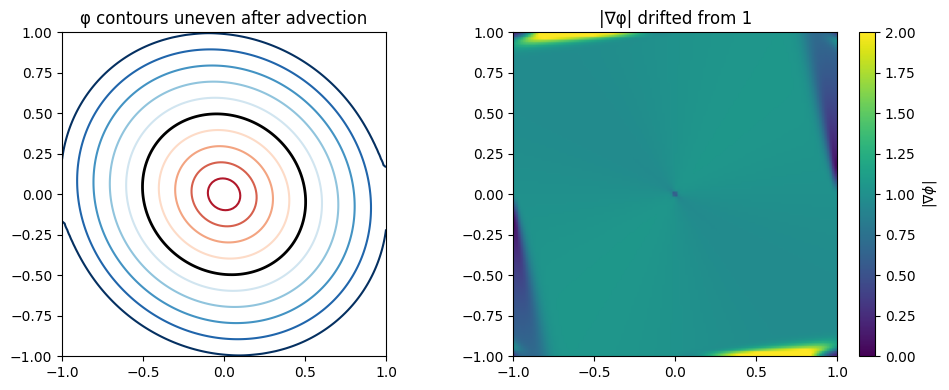

In [7]:
def upwind_advect(phi, u, v, dt, h):
    # First-order upwind for ∂φ/∂t + u φ_x + v φ_y = 0
    phi_x_plus  = (np.roll(phi, -1, 1) - phi) / h
    phi_x_minus = (phi - np.roll(phi,  1, 1)) / h
    phi_y_plus  = (np.roll(phi, -1, 0) - phi) / h
    phi_y_minus = (phi - np.roll(phi,  1, 0)) / h
    phi_x = np.where(u > 0, phi_x_minus, phi_x_plus)
    phi_y = np.where(v > 0, phi_y_minus, phi_y_plus)
    return phi - dt * (u * phi_x + v * phi_y)

# Shear-rotation velocity
U = -Y
V =  X * 0.5   # anisotropic → stretches φ

phi_adv = phi.copy()
dt = 0.2 * h / max(np.abs(U).max(), np.abs(V).max())
for _ in range(60):
    phi_adv = upwind_advect(phi_adv, U, V, dt, h)

mag_adv = grad_mag(phi_adv, h)
print(f'After advection |∇φ|: min = {mag_adv.min():.3f}, max = {mag_adv.max():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].contour(X, Y, phi_adv, levels=np.linspace(-0.5, 0.5, 11), cmap='RdBu')
ax[0].contour(X, Y, phi_adv, levels=[0], colors='k', linewidths=2)
ax[0].set_aspect('equal'); ax[0].set_title('φ contours uneven after advection')
im = ax[1].imshow(mag_adv, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='viridis', vmin=0, vmax=2)
plt.colorbar(im, ax=ax[1], label=r'$|\nabla \phi|$')
ax[1].set_title('|∇φ| drifted from 1')
plt.tight_layout()
plt.show()

The zero set still represents a circle-ish shape, but `|∇φ|` now ranges well beyond 1. If we tried to compute `κ = Δφ` here, it would be meaningless.

## 6. Reinitialization: restore `|∇φ| = 1` without moving the zero set

Solve `∂φ/∂τ + sign(φ₀)(|∇φ| − 1) = 0` in pseudo-time. Sussman, Smereka, Osher (1994).

After reinit |∇φ|: min = 0.040, max = 1.055


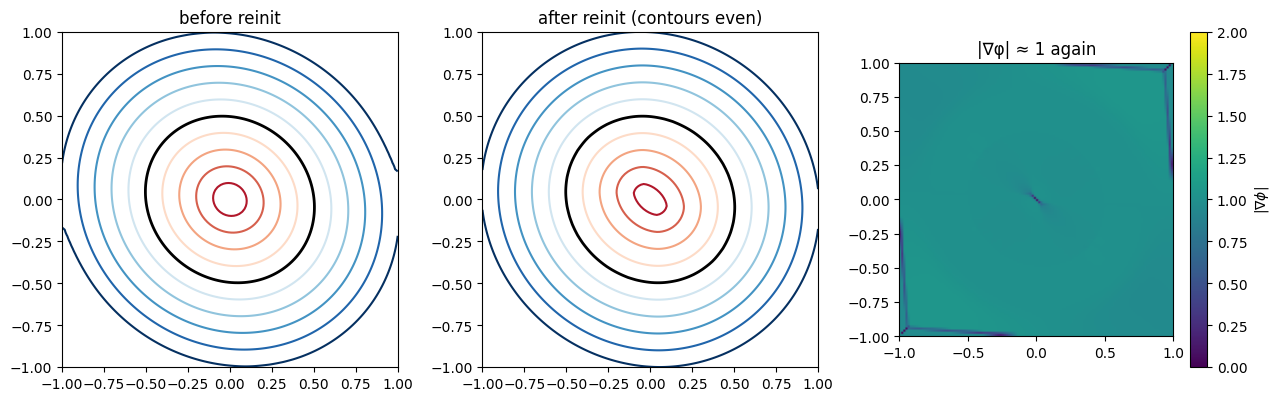

In [8]:
def reinit_step(phi, phi0, dtau, h):
    # Godunov scheme for |∇φ|, from Sussman-Smereka-Osher
    phi_x_plus  = (np.roll(phi, -1, 1) - phi) / h
    phi_x_minus = (phi - np.roll(phi,  1, 1)) / h
    phi_y_plus  = (np.roll(phi, -1, 0) - phi) / h
    phi_y_minus = (phi - np.roll(phi,  1, 0)) / h
    sgn = phi0 / np.sqrt(phi0**2 + h**2)  # smoothed sign
    a_p = np.maximum(phi_x_minus, 0); a_m = np.minimum(phi_x_minus, 0)
    b_p = np.maximum(phi_x_plus,  0); b_m = np.minimum(phi_x_plus,  0)
    c_p = np.maximum(phi_y_minus, 0); c_m = np.minimum(phi_y_minus, 0)
    d_p = np.maximum(phi_y_plus,  0); d_m = np.minimum(phi_y_plus,  0)
    grad = np.where(
        phi0 > 0,
        np.sqrt(np.maximum(a_p**2, b_m**2) + np.maximum(c_p**2, d_m**2)),
        np.sqrt(np.maximum(a_m**2, b_p**2) + np.maximum(c_m**2, d_p**2))
    )
    return phi - dtau * sgn * (grad - 1)

phi_reinit = phi_adv.copy()
phi0 = phi_adv.copy()
dtau = 0.3 * h
for _ in range(80):
    phi_reinit = reinit_step(phi_reinit, phi0, dtau, h)

mag_reinit = grad_mag(phi_reinit, h)
print(f'After reinit |∇φ|: min = {mag_reinit.min():.3f}, max = {mag_reinit.max():.3f}')

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].contour(X, Y, phi_adv, levels=np.linspace(-0.5, 0.5, 11), cmap='RdBu')
ax[0].contour(X, Y, phi_adv, levels=[0], colors='k', linewidths=2)
ax[0].set_title('before reinit'); ax[0].set_aspect('equal')
ax[1].contour(X, Y, phi_reinit, levels=np.linspace(-0.5, 0.5, 11), cmap='RdBu')
ax[1].contour(X, Y, phi_reinit, levels=[0], colors='k', linewidths=2)
ax[1].set_title('after reinit (contours even)'); ax[1].set_aspect('equal')
im = ax[2].imshow(mag_reinit, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='viridis', vmin=0, vmax=2)
plt.colorbar(im, ax=ax[2], label=r'$|\nabla \phi|$')
ax[2].set_title('|∇φ| ≈ 1 again')
plt.tight_layout()
plt.show()

**Observe:**
- The black zero-contour barely moves during reinit (it should be identical, up to O(h) error).
- The other level-set contours spread out to equal spacing.
- `|∇φ|` is back to ≈ 1 over most of the domain.

This is the full level-set bookkeeping you'll run every frame of the fire simulation.

## Exercises

1. Change `R` and confirm that `κ` on the front tracks `1/R`.
2. Initialize with `ψ = x² + y² − R²` (not an SDF), run reinit, watch it converge to an SDF.
3. Add a flame speed: modify `upwind_advect` to use `w = V − S·n` where `n = ∇φ`. With `V=0` this shrinks the circle at speed `S` — the front burning into fuel.